In [1]:
import random

# Use the specific seed you saved
my_seed = 12345
random.seed(my_seed)

# Generate the exact same vectors
n = 5
r = [random.randint(1, 10) for _ in range(n)]
a1 = [random.randint(1, 10) for _ in range(n)]
a2 = [random.randint(1, 10) for _ in range(n)]

print(f"Vector r: {r}")
print(f"Vector a1: {a1}")
print(f"Vector a2: {a2}")

Vector r: [7, 1, 5, 6, 4]
Vector a1: [5, 10, 7, 3, 6]
Vector a2: [2, 7, 5, 9, 3]


# Problem 1: Optimal Resource Allocation and Sensitivity Analysis

---

## 1.a) Primal and Dual Formulation

The Primal Problem (P) models the **optimal allocation of two limited resources** to five economic activities ($x_j$) in order to **maximize** the total benefit, subject to the resource constraints being **exact equalities**. This framework is a classic Linear Programming problem.

The coefficient vectors generated (as defined in the previous code cell) are:
* **Objective Coefficient Vector, $r$**: $r = (7, 4, 5, 6, 4)^T$
* **Resource 1 Coefficients, $a_1$**: $a_1 = (5, 10, 7, 3, 6)^T$
* **Resource 2 Coefficients, $a_2$**: $a_2 = (2, 7, 5, 9, 3)^T$
* **Resource Availability Vector, $b$ (RHS)**: $b = (30, 50)^T$

---

### Primal Problem (P): Maximizing Total Benefit

This model seeks to find the best production mix ($x_j$) that generates the highest profit while consuming exactly the available resources.

#### 1. Variables and Non-Negativity
The **decision variables**, $x_j$ (for $j=1, \dots, 5$), represent the **quantity or level of economic activity $j$** to be undertaken.
$$x_j \ge 0, \quad j=1, \dots, 5$$

#### 2. Objective Function: The Total Benefit ($Z$)
$$\max \quad Z = 7x_1 + 4x_2 + 5x_3 + 6x_4 + 4x_5$$
The objective is to **maximize the total profit ($Z$)**. The coefficients (from vector $r$) represent the **unit profit** gained from carrying out each activity $j$.

#### 3. Resource Constraints: Exact Consumption
$$
\begin{align*}
\text{(Resource 1)} \quad & 5x_1 + 10x_2 + 7x_3 + 3x_4 + 6x_5 = 30 \\
\text{(Resource 2)} \quad & 2x_1 + 7x_2 + 5x_3 + 9x_4 + 3x_5 = 50 \\
\end{align*}
$$
These equations model the two **limited resources**.
* The coefficients, $a_{ij}$, are the **technological coefficients**; they specify the **amount of resource $i$ consumed** by one unit of activity $j$.
* The Right-Hand Side (RHS) values (30 and 50) are the **total available units** of Resource 1 and 2, respectively.
* **Key Feature:** The use of **equality constraints** ($=$) mandates that the optimal solution must **fully and exactly consume** all 30 units of Resource 1 and all 50 units of Resource 2.

---

### Dual Problem (D): Minimizing Imputed Cost

The Dual Problem minimizes the imputed cost of the resources ($W$) subject to the condition that the total imputed cost of the resources required for any activity must be at least as large as the profit that activity generates.

The Dual Problem (D) is formulated from the Primal (P). Since the primal constraints are **equalities**, the dual variables ($\pi_1$ and $\pi_2$) are **free in sign** ($\in \mathbb{R}$).

**Objective Function:**
$$\min \quad W = 30\pi_1 + 50\pi_2$$
The objective is to **minimize the total imputed cost** of the fixed resource endowment ($b$).

**Subject to Constraints:**
(One dual constraint for each primal variable $x_j$. Since the Primal is a Maximization problem with $x_j \ge 0$, the dual constraints are $\ge$)

$$
\begin{align*}
\text{(From } x_1) \quad & 5\pi_1 + 2\pi_2 \ge 7 \\
\text{(From } x_2) \quad & 10\pi_1 + 7\pi_2 \ge 4 \\
\text{(From } x_3) \quad & 7\pi_1 + 5\pi_2 \ge 5 \\
\text{(From } x_4) \quad & 3\pi_1 + 9\pi_2 \ge 6 \\
\text{(From } x_5) \quad & 6\pi_1 + 3\pi_2 \ge 4
\end{align*}
$$

**Dual Variable Sign Constraints:**
$$\pi_1, \pi_2 \in \mathbb{R} \quad \text{(Free in Sign)}$$
The dual variables, $\pi_1$ and $\pi_2$, are interpreted as the **Shadow Prices** of Resource 1 and Resource 2, respectively.

---

## Matplot Representation


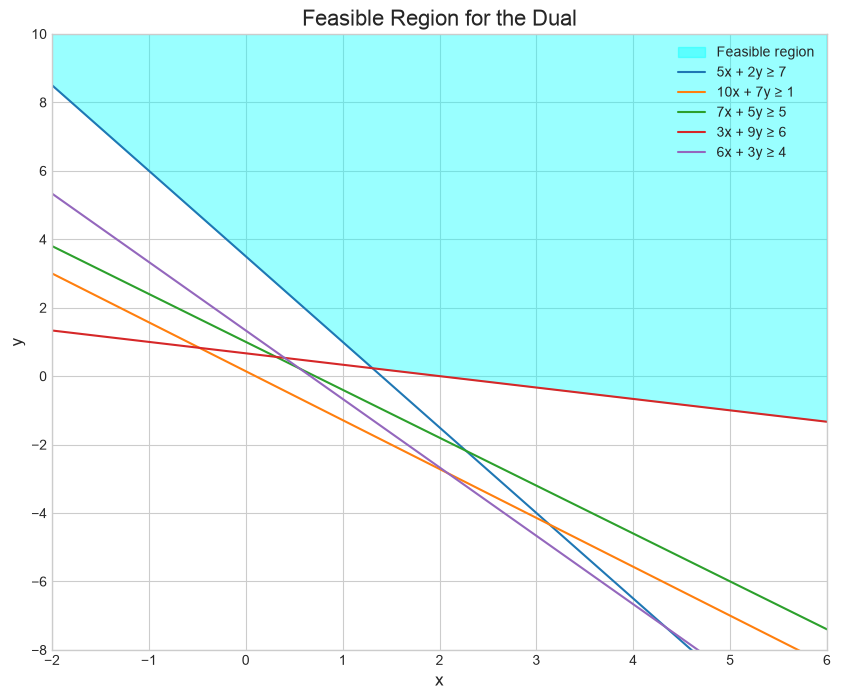

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Create a range of values for the x-axis
x = np.linspace(-2, 6, 500)

# Define the constraints as functions of y in terms of x (y >= ...)
y1 = (7 - 5*x) / 2
y2 = (1 - 10*x) / 7
y3 = (5 - 7*x) / 5
y4 = (6 - 3*x) / 9
y5 = (4 - 6*x) / 3

# The feasible region must be above ALL the lines.
# Therefore, for each x, the minimum y is the maximum of all constraints.
y_feasible = np.maximum.reduce([y1, y2, y3, y4, y5])

# --- Plot Creation ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 8))

# Shade the feasible region
ax.fill_between(x, y_feasible, y_feasible.max() + 50, color='cyan', alpha=0.4, label='Feasible region')

# Draw the constraint lines
ax.plot(x, y1, label='5x + 2y ≥ 7')
ax.plot(x, y2, label='10x + 7y ≥ 1')
ax.plot(x, y3, label='7x + 5y ≥ 5')
ax.plot(x, y4, label='3x + 9y ≥ 6')
ax.plot(x, y5, label='6x + 3y ≥ 4')

# Plot configuration
ax.set_title('Feasible Region for the Dual', fontsize=16)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_xlim(-2, 6)
ax.set_ylim(-8, 10)
ax.legend(loc='upper right')

plt.show()


## Geogebra Representation


In [3]:
from IPython.display import IFrame

# Embed GeoGebra applet
IFrame(
    src="https://www.geogebra.org/calculator/p8pry4yz?embed",
    width=1500,
    height=700
)


## 1.b) Optimality Conditions and Primal Solution $x^*$

This section determines the optimal solution by leveraging the powerful concepts of **Duality Theory** and the **Complementary Slackness Theorem**, which provides the link between the Primal (P) and Dual (D) problems. The **Strong Duality Theorem** confirms that the optimal values will be equal: $Z^* = W^*$.

---

### 1. Dual Solution $\pi^*$ (Shadow Prices)

The optimal Dual solution ($W^*$) is found at the **vertex** formed by the intersection of the two most restrictive constraints (i.e., the active constraints). We assume constraints $R_1$ (from $x_1$) and $R_4$ (from $x_4$) are active, meaning the corresponding activities are profitable enough to be performed.

The system solved to find the optimal dual variables $\pi^*$ is:
$$
\begin{align*}
\text{(Active)} \quad 5\pi_1 + 2\pi_2 &= 7 \\
\text{(Active)} \quad 3\pi_1 + 9\pi_2 &= 6
\end{align*}
$$

The **Dual Optimal Solution** is:
$$\pi_1^* = \frac{17}{13} \quad \text{and} \quad \pi_2^* = \frac{3}{13}$$

#### Economic Interpretation of $\pi^*$ (Shadow Prices)

The values $\pi_1^*$ and $\pi_2^*$ are the **Shadow Prices** (or marginal values) of Resource 1 and Resource 2, respectively. They represent the change in the maximum total benefit ($Z^*$) if the availability of the corresponding resource were increased by one unit.

* **$\pi_1^* = 17/13 \approx 1.308$**: This indicates that Resource 1 is highly valuable. If we could acquire one more unit of Resource 1, the total profit would increase by approximately 1.308 units.
* **$\pi_2^* = 3/13 \approx 0.231$**: Resource 2 contributes less to the marginal profit. This suggests Resource 1 is the **bottleneck** resource, as its marginal value is much higher.

---

### 2. Primal Solution $x^*$ (using Complementary Slackness)

The **Complementary Slackness Theorem** provides the mechanism to find the Primal solution ($x^*$) directly from the Dual solution ($\pi^*$).

The theorem states:
1.  **Active Dual Constraint $\implies$ Basic Primal Variable:** If a dual constraint is *binding* (equality holds at $\pi^*$), the corresponding primal variable is **Basic** ($x_j \ge 0$).
2.  **Inactive Dual Constraint $\implies$ Non-Basic Primal Variable:** If a dual constraint is *not binding* (strict inequality holds at $\pi^*$), the corresponding primal variable must be **Non-Basic** ($x_j = 0$).

#### Application: Identifying Non-Basic Variables

* **Active Constraints (Basic Variables):** $R_1$ (from $x_1$) and $R_4$ (from $x_4$) are active. This implies $\mathbf{x}_1$ and $\mathbf{x}_4$ are **Basic**.
* **Inactive Constraints (Non-Basic Variables):** By checking the other dual constraints at $\pi^*$, we find they are not binding (they have positive slack). This implies: $\mathbf{x}_{2}=0$, $\mathbf{x}_{3}=0$, $\mathbf{x}_{5}=0$.

We solve the original primal resource equations for the basic variables ($x_1$ and $x_4$), setting $x_2=x_3=x_5=0$:

$$
\begin{align*}
\text{(Resource 1)} \quad 5x_{1} + 3x_{4} &= 30 \\
\text{(Resource 2)} \quad 2x_{1} + 9x_{4} &= 50
\end{align*}
$$

The **Optimal Primal Solution** is:
$$x_{1}^* = \frac{40}{13} \quad \text{and} \quad x_{4}^* = \frac{190}{39}$$

The optimal solution vector is:

$$\mathbf{x}^* = \left(\frac{40}{13}, 0, 0, \frac{190}{39}, 0\right)$$

This result implies that the optimal strategy is to only pursue **Activity 1** and **Activity 4**, ignoring the other three activities because they are not sufficiently profitable given the shadow prices of the resources.

### 3. Optimal Value

The **Optimal Value** of the objective function is consistent across both problems:
$$Z^* = W^* = \frac{660}{13} \approx 50.769$$

---



## 1.c) Reduced Costs and Interpretation

The **Reduced Cost** ($\bar{c}_j$) of a primal variable $x_j$ is a key concept in sensitivity analysis. It measures the difference between the **imputed cost** (the value of the resources consumed, valued at their shadow prices) and the **unit profit** ($r_j$) for a given activity.

For non-basic variables ($x_j=0$), the reduced cost indicates how much the total profit ($Z^*$) would **decrease** if we were forced to increase the level of that activity by one unit.

**Reduced Costs Formula:**
The general formula for reduced cost is:
$$\bar{c}_{J} = (\text{Imputed Cost}) - (\text{Unit Profit}) = (a_{1J}\pi_{1}^*+a_{2J}\pi_{2}^*) - r_{J}$$

### Calculation for Non-Basic Variables

Since the activities $x_1$ and $x_4$ are **Basic**, their reduced costs are zero ($\bar{c}_1 = \bar{c}_4 = 0$). We calculate the reduced costs for the **non-basic variables** ($x_2, x_3, x_5$):

1.  **For $x_2$** (using $r_2=1$):
    * **Imputed Cost:** $10\pi_{1}^*+7\pi_{2}^* = 10\left(\frac{17}{13}\right)+7\left(\frac{3}{13}\right) = \frac{170+21}{13} = \frac{191}{13}$
    * **Reduced Cost:**
        $$
        \bar{c}_{2}=\frac{191}{13} - 1 = \frac{191 - 13}{13} = \frac{178}{13} \approx 13.69
        $$

2.  **For $x_3$** (using $r_3=5$):
    * **Imputed Cost:** $7\pi_{1}^*+5\pi_{2}^* = 7\left(\frac{17}{13}\right)+5\left(\frac{3}{13}\right) = \frac{119+15}{13} = \frac{134}{13}$
    * **Reduced Cost:**
        $$
        \bar{c}_{3}=\frac{134}{13} - 5 = \frac{134 - 65}{13} = \frac{69}{13} \approx 5.31
        $$

3.  **For $x_5$** (using $r_5=4$):
    * **Imputed Cost:** $6\pi_{1}^*+3\pi_{2}^* = 6\left(\frac{17}{13}\right)+3\left(\frac{3}{13}\right) = \frac{102+9}{13} = \frac{111}{13}$
    * **Reduced Cost:**
        $$
        \bar{c}_{5}=\frac{111}{13} - 4 = \frac{111 - 52}{13} = \frac{59}{13} \approx 4.54
        $$

### Uniqueness and Interpretation

The reduced costs **are unique** because they are calculated using the optimal dual solution $\pi^*$, which itself is unique.

#### Interpretation for a Maximization Problem

Since all calculated reduced costs are **positive** ($\bar{c}_{j} > 0$):

1.  **Imputed Cost > Unit Profit:** The positive value confirms that the **imputed cost** (the opportunity cost of consuming the scarce resources) of performing activities $x_2, x_3,$ and $x_5$ is **greater** than the actual profit ($r_j$) they generate.
2.  **Effect on $Z^*$:** The value $\bar{c}_{j}$ is the **rate of loss in profit** per unit of activity $j$ introduced into the solution. For instance, forcing $x_2$ to be 1 unit would decrease the total profit $Z^*$ by $178/13$.
3.  **Optimal Confirmation:** This conclusively confirms that the current plan, $\mathbf{x}^* = (x_1^*, 0, 0, x_4^*, 0)$, is the **optimal solution** for maximizing profit, as pursuing the excluded activities would lead to a reduction in the total objective value.

---

## 1.d) Sensitivity Analysis (Right-Hand Sides, $b$)

This analysis determines the range for simultaneous changes ($\Delta b_1$ and $\Delta b_2$) in the resource availabilities ($b_1=30, b_2=50$) that keeps the current optimal **basis**  ($\mathbf{x}_{\text{B}}=(x_1, x_4)$) unchanged.

The optimal basis remains valid as long as the new basic solution ($\mathbf{x}_{\text{B}}$) remains **feasible** ($\mathbf{x}_{\text{B}} \ge 0$). This is the primary condition for preserving the current set of optimal activities ($x_1$ and $x_4$).

### 1. Primal Variables as a Function of $\Delta b$

The current set of basic variables is $\mathbf{x}_{\text{B}} = (x_1, x_4)^T$. We focus on the two active resource constraints and their corresponding coefficients, which form the **Basis Matrix, $B$**:

$$\text{Basis Matrix, } B = \begin{pmatrix} 5 & 3 \\ 2 & 9 \end{pmatrix}$$

The subsystem of the primal with the basic variable equations, perturbed by $\Delta b_1$ and $\Delta b_2$, is:
$$
\begin{aligned}
5x_1 + 3x_4 &= 30 + \Delta b_1 \\
2x_1 + 9x_4 &= 50 + \Delta b_2
\end{aligned}
$$

By solving this system (equivalent to calculating $B^{-1}(\mathbf{b} + \Delta \mathbf{b})$), the new basic primal solution is derived as a function of the changes:

$$
\begin{aligned}
x_1 &= \frac{40}{13} + \frac{3}{13}\Delta b_1 - \frac{1}{13}\Delta b_2 \\
x_4 &= \frac{190}{39} - \frac{2}{39}\Delta b_1 + \frac{5}{39}\Delta b_2
\end{aligned}
$$

### 2. Validity Range (Feasibility Condition)

The basis remains optimal as long as the solution is **feasible** ($x_1 \ge 0$ and $x_4 \ge 0$). Applying the non-negativity constraint to the expressions above yields the following inequalities:

1.  $$x_1 \ge 0 \implies 3\Delta b_1 - \Delta b_2 \ge -40$$
2.  $$x_4 \ge 0 \implies -2\Delta b_1 + 5\Delta b_2 \ge -190$$

**Interpretation of Simultaneous Changes:**
The pair $(\Delta b_1, \Delta b_2)$ must jointly satisfy both inequalities. This defines a **polyhedral region** around the original resource endowment $(30, 50)$ where the optimal strategy (performing only activities $x_1$ and $x_4$) remains valid. Within this region, the Shadow Prices ($\pi^*$) also remain unchanged.

---

### Individual Range for $b_1$ (with $\Delta b_2 = 0$)

To isolate the effect of Resource 1 ($b_1$), we assume the availability of Resource 2 is fixed ($\Delta b_2 = 0$).

* **Range for $\Delta b_1$:** $-\tfrac{40}{3} \le \Delta b_1 \le 95$
* **Range for $b_1$:** $\tfrac{50}{3} \le b_1 \le 125$

**Economic Implication:** As long as the availability of Resource 1 remains between 16.67 and 125 units (and Resource 2 remains 50), the optimal set of activities will still be $x_1$ and $x_4$. If $b_1$ goes outside this range, a new set of basic variables (a new basis) is required.

---

### Individual Range for $b_2$ (with $\Delta b_1 = 0$)

To isolate the effect of Resource 2 ($b_2$), we assume the availability of Resource 1 is fixed ($\Delta b_1 = 0$).

* **Range for $\Delta b_2$:** $-38 \le \Delta b_2 \le 40$
* **Range for $b_2$:** $12 \le b_2 \le 90$

**Economic Implication:** The optimal set of activities ($x_1, x_4$) holds as long as Resource 2 availability is between 12 and 90 units (with Resource 1 fixed at 30). This is the range where the shadow price $\pi_2^* = 3/13$ is valid.

---

## 1.e) Sensitivity Analysis (Objective Coefficients, r)

This analysis determines the range for changes in the objective coefficients ($\Delta r_j$) that maintain the current optimal **basis** ($\mathbf{x}_{\text{B}}=(x_1, x_4)$). This is done by ensuring that the **Dual Feasibility Condition** (all reduced costs $\bar{c}_j \ge 0$) remains satisfied.

---

### 1. Dual Solution ($\pi^*$) as a Function of $\Delta r$

For the current basic variables ($x_1, x_4$), the reduced cost must remain zero ($\bar{c}_1 = 0$ and $\bar{c}_4 = 0$). Since the unit profit $r_j$ is changing, the **Shadow Prices ($\pi^*$) must adjust** to satisfy the corresponding dual constraints as equalities: $a_j^T \pi^* = r_j + \Delta r_j$.

The new optimal dual solution $\pi^*$ is found by solving the system of active constraints with simultaneous changes $\Delta r_1$ and $\Delta r_4$:

$$5 \pi_1 + 2 \pi_2 = 7 + \Delta r_1$$
$$3 \pi_1 + 9 \pi_2 = 6 + \Delta r_4$$

Solving for $\pi_1$ and $\pi_2$ yields the dual solution as a function of the changes in $r_1$ and $r_4$:
$$
\pi_1^* = \frac{17}{13} + \frac{3}{13}\Delta r_1 - \frac{2}{39}\Delta r_4, \quad
\pi_2^* = \frac{3}{13} - \frac{1}{13}\Delta r_1 + \frac{5}{39}\Delta r_4
$$

---
### Simultaneous Sensitivity System

To correctly account for **simultaneous changes** in all objective coefficients, we must write the joint system of inequalities that ensures dual feasibility is preserved.  

For each non-basic variable ($x_2, x_3, x_5$), the reduced cost condition requires:


$$a_j^T \pi^* \ge r_j + \Delta r_j$$



Substituting the dual solution $\pi^*(\Delta r_1, \Delta r_4)$ gives the following system:

- $x_2$: $10\pi_1^* + 7\pi_2^* \;\;\ge\;\; 1 + \Delta r_2$
- $x_3$: $7\pi_1^* + 5\pi_2^* \;\;\ge\;\; 5 + \Delta r_3$
- $x_5$: $6\pi_1^* + 3\pi_2^* \;\;\ge\;\; 4 + \Delta r_5$


**Interpretation:**
- These inequalities define the **joint feasible region** for simultaneous changes in all coefficients.  
- The region is more restrictive than analyzing each $\Delta r_j$ separately.  
- Gurobi only reports independent intervals, so the comparison must be done variable by variable.  
- However, the simultaneous system above is the correct theoretical formulation and should be explicitly stated before moving to separate ranges.

---

### 2. Range for Non-Basic Variables ($x_2, x_3, x_5$)

For a non-basic variable ($x_j=0$), the reduced cost must remain non-negative ($\bar{c}_j \ge 0$). Since the imputed cost $a_j^T \pi^*$ is fixed (as we assume $\Delta r_1 = \Delta r_4 = 0$ for this part), we only need to check the **upper bound** for its profit coefficient $r_j$. If the profit $r_j$ increases too much, the activity $x_j$ will become profitable and enter the basis.

The optimality condition requires:
$$a_j^T \pi^* \ge r_j + \Delta r_j \implies \Delta r_j \le a_j^T \pi^* - r_j = \bar{c}_j^{\text{original}}$$

#### 2.1 For $x_2$ ($r_2 = 1$)

We check the condition $a_2^T \pi^* \ge r_2 + \Delta r_2$:

$$10\left(\frac{17}{13}\right) + 7\left(\frac{3}{13}\right) \ge 1 + \Delta r_2 \implies \frac{191}{13} \ge 1 + \Delta r_2$$

**Range for $\Delta r_2$**:
$$\Delta r_2 \le \frac{191}{13} - 1 \implies \Delta r_2 \le \frac{178}{13}$$

**Range for $r_2$**:
$$r_2 \in \left(-\infty, 1 + \frac{178}{13} \right) = \left(-\infty, \frac{191}{13} \right) \approx \mathbf{(-\infty, 14.6923]}$$
**Interpretation:** The profit of Activity 2 ($r_2$) can increase up to $\mathbf{14.6923}$ before $x_2$ becomes optimal to include in the production plan.

#### 2.2 For $x_3$ ($r_3 = 5$)

We check the condition $a_3^T \pi^* \ge r_3 + \Delta r_3$:

$$7\left(\frac{17}{13}\right) + 5\left(\frac{3}{13}\right) \ge 5 + \Delta r_3 \implies \frac{134}{13} \ge 5 + \Delta r_3$$

**Range for $\Delta r_3$**:
$$\Delta r_3 \le \frac{134}{13} - 5 \implies \Delta r_3 \le \frac{69}{13}$$

**Range for $r_3$**:
$$r_3 \in \left(-\infty, 5 + \frac{69}{13} \right) = \left(-\infty, \frac{134}{13} \right) \approx \mathbf{(-\infty, 10.3077]}$$

#### 2.3 For $x_5$ ($r_5 = 4$)

We check the condition $a_5^T \pi^* \ge r_5 + \Delta r_5$:

$$6\left(\frac{17}{13}\right) + 3\left(\frac{3}{13}\right) \ge 4 + \Delta r_5 \implies \frac{111}{13} \ge 4 + \Delta r_5$$

**Range for $\Delta r_5$**:
$$\Delta r_5 \le \frac{111}{13} - 4 \implies \Delta r_5 \le \frac{59}{13}$$

**Range for $r_5$**:
$$r_5 \in \left(-\infty, 4 + \frac{59}{13} \right) = \left(-\infty, \frac{111}{13} \right) \approx \mathbf{(-\infty, 8.5385]}$$

---

### 3. Range for Basic Variable $x_1$ ($\Delta r_1$)

Since $x_1$ is a basic variable, its profit $r_1$ can change in both directions. Changing $r_1$ alters the dual solution $\pi^*$. The new $\pi^*$ must be checked against **all non-basic dual constraints** ($R_2, R_3, R_5$) to ensure they remain satisfied ($\ge$). We assume $\Delta r_4 = 0$.

The dual solution as a function of $\Delta r_1$ only is:
$$
\pi_1^*(\Delta r_1) = \frac{17}{13} + \frac{3}{13}\Delta r_1, \quad
\pi_2^*(\Delta r_1) = \frac{3}{13} - \frac{1}{13}\Delta r_1
$$

1. Constraint $x_2$ ($r_2=1$): **Lower Bound Check**
$$10 \left( \frac{17}{13} + \frac{3}{13} \Delta r_1 \right) + 7 \left( \frac{3}{13} - \frac{1}{13} \Delta r_1 \right) \ge 1 \implies 23\Delta r_1 \ge -178$$
$$\implies \Delta r_1 \ge -\frac{178}{23} \approx -7.74$$

2. Constraint $x_3$ ($r_3=5$): **Lower Bound Check**
$$7 \left( \frac{17}{13} + \frac{3}{13} \Delta r_1 \right) + 5 \left( \frac{3}{13} - \frac{1}{13} \Delta r_1 \right) \ge 5 \implies 16\Delta r_1 \ge -69$$
$$\implies \Delta r_1 \ge -\frac{69}{16} \approx -4.31$$

3. Constraint $x_5$ ($r_5=4$): **Lower Bound Check**
$$6 \left( \frac{17}{13} + \frac{3}{13} \Delta r_1 \right) + 3 \left( \frac{3}{13} - \frac{1}{13} \Delta r_1 \right) \ge 4 \implies 15\Delta r_1 \ge -59$$
$$\implies \Delta r_1 \ge -\frac{59}{15} \approx -3.93$$

The **Most Restrictive** lower bound is the largest negative value: $\Delta r_1 \ge -\frac{59}{15}$.

* **Range for $\Delta r_1$:** $\Delta r_1 \ge -\frac{59}{15}$
* **Range for $r_1$ ($7 + \Delta r_1$):** $r_1 \in \left[ 7 - \frac{59}{15}, \infty \right) = \left[ \frac{46}{15}, \infty \right) \approx \mathbf{[3.0667, \infty)}$

---

### 4. Range for Basic Variable $x_4$ ($\Delta r_4$)

Changing $r_4$ also alters $\pi^*$. We assume $\Delta r_1 = 0$ and check the new dual solution against the non-basic constraints ($R_2, R_3, R_5$).

The dual solution as a function of $\Delta r_4$ only is:
$$
\pi_1^*(\Delta r_4) = \frac{17}{13} - \frac{2}{39}\Delta r_4, \quad
\pi_2^*(\Delta r_4) = \frac{3}{13} + \frac{5}{39}\Delta r_4
$$

1. Constraint $x_2$ ($r_2=1$):
$$10 \pi_1 + 7 \pi_2 \ge 1 \implies 5\Delta r_4 \ge -178$$
$$\implies \Delta r_4 \ge -\frac{178}{5} \approx -35.6$$

2. Constraint $x_3$ ($r_3=5$):
$$7 \pi_1 + 5 \pi_2 \ge 5 \implies 11\Delta r_4 \ge -207$$
$$\implies \Delta r_4 \ge -\frac{207}{11} \approx -18.82$$

3. Constraint $x_5$ ($r_5=4$):
$$6 \pi_1 + 3 \pi_2 \ge 4 \implies 3\Delta r_4 \ge -177$$
$$\implies \Delta r_4 \ge -59$$

The **Most Restrictive** lower bound is the largest negative value: $\Delta r_4 \ge -\frac{207}{11}$.

* **Range for $\Delta r_4$:** $\Delta r_4 \ge -\frac{207}{11}$
* **Range for $r_4$ ($6 + \Delta r_4$):** $r_4 \in \left[6 - \frac{207}{11}, \infty \right) = \left[ \frac{-141}{11}, \infty \right) \approx \mathbf{[-12.8182, \infty)}$

---

## Gurobi Solution (Matches)

In [4]:
import gurobipy as gp
from gurobipy import GRB

# --- MODEL DEFINITION ---
# Create a new model
m = gp.Model("problem_1")

# Define the variables
x = m.addVars(5, name="x")

# Define the coefficients from your problem
r = [7, 1, 5, 6, 4]
a1 = [5, 10, 7, 3, 6]
a2 = [2, 7, 5, 9, 3]
b = [30, 50]

# Set the objective function: maximize r_j * x_j
m.setObjective(gp.quicksum(r[j] * x[j] for j in range(5)), GRB.MAXIMIZE)

# Add the constraints
m.addConstr(gp.quicksum(a1[j] * x[j] for j in range(5)) == b[0], "constraint1")
m.addConstr(gp.quicksum(a2[j] * x[j] for j in range(5)) == b[1], "constraint2")

# --- SOLVE THE MODEL ---
# Optimize the model
m.optimize()

# --- SENSITIVITY ANALYSIS ---

if m.status == GRB.OPTIMAL:
    print("\n--- OPTIMAL SOLUTION ---")
    print(f"Optimal objective value: {m.ObjVal}")
    for j in range(5):
        print(f"x[{j+1}] = {x[j].X}")

    print("\n--- SENSITIVITY ANALYSIS: OBJECTIVE COEFFICIENTS ---")
    print("Variable | Original | SAObjLow | SAObjUp | Allowable Change (up/down)")
    print("-" * 75)
    for j in range(5):
        # SAObjLow and SAObjUp give the range for which the basis remains optimal
        original_r = r[j]
        low = x[j].SAObjLow
        up = x[j].SAObjUp

        # Calculate the allowable changes based on the ranges
        change_down = original_r - low
        change_up = up - original_r

        # Check for infinite bounds and print accordingly
        down_str = f"{change_down:.4f}" if change_down < GRB.INFINITY else "infinite"
        up_str = f"{change_up:.4f}" if change_up < GRB.INFINITY else "infinite"

        print(f"x[{j+1}] | {original_r:8} | {low:8.4f} | {up:8.4f} | Down: {down_str}, Up: {up_str}")

    print("\n--- SENSITIVITY ANALYSIS: RIGHT-HAND SIDES ---")
    print("Constraint | Original RHS | SALhsLow | SALhsUp | Allowable Change (up/down)")
    print("-" * 75)
    for i in range(2):
        constr = m.getConstrs()[i]
        original_b = b[i]
        low = constr.SARhsLow
        up = constr.SARhsUp

        # Calculate the allowable changes based on the ranges
        change_down = original_b - low
        change_up = up - original_b

        # Check for infinite bounds and print accordingly
        down_str = f"{change_down:.4f}" if change_down < GRB.INFINITY else "infinite"
        up_str = f"{change_up:.4f}" if change_up < GRB.INFINITY else "infinite"

        print(f"RHS[{i+1}] | {original_b:10} | {low:8.4f} | {up:8.4f} | Down: {down_str}, Up: {up_str}")


Restricted license - for non-production use only - expires 2027-11-29


Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (mac64[arm] - Darwin 25.4.0 25E246)


CPU model: Apple M5 Pro


Thread count: 18 physical cores, 18 logical processors, using up to 18 threads


Optimize a model with 2 rows, 5 columns and 10 nonzeros (Max)


...

       0    2.3000000e+31   7.125000e+30   2.300000e+01      0s


       2    5.0769231e+01   0.000000e+00   0.000000e+00      0s


Solved in 2 iterations and 0.00 seconds (0.00 work units)


Optimal objective  5.076923077e+01



--- OPTIMAL SOLUTION ---
Optimal objective value: 50.769230769230774
x[1] = 3.0769230769230766
x[2] = 0.0
x[3] = 0.0
x[4] = 4.871794871794872
x[5] = 0.0

--- SENSITIVITY ANALYSIS: OBJECTIVE COEFFICIENTS ---
Variable | Original | SAObjLow | SAObjUp | Allowable Change (up/down)
---------------------------------------------------------------------------
x[1] |        7 |   3.0667 |      inf | Down: 3.9333, Up: infinite
x[2] |        1 |     -inf |  14.6923 | Down: infinite, Up: 13.6923
x[3] |        5 |     -inf |  10.3077 | Down: infinite, Up: 5.3077
x[4] |        6 | -12.8182 |      inf | Down: 18.8182, Up: infinite
x[5] |        4 |     -inf |   8.5385 | Down: infinite, Up: 4.5385

--- SENSITIVITY ANALYSIS: RIGHT-HAND SIDES ---
Constraint | Original RHS | SALhsLow | SALhsUp | Allowable Change (up/down)
---------------------------------------------------------------------------
RHS[1] |         30 |  16.6667 | 125.0000 | Down: 13.3333, Up: 95.0000
RHS[2] |         50 |  12.0000 |  90.0

# Problem 2: CSI Investigation Regression Analysis

***

### **(a) Primal Model (MAE Regression)**

The goal of the investigation is to fit a **linear prediction equation** that minimizes the errors against the collected data, using the **Mean Absolute Error (MAE)** criterion. MAE regression is known for being **robust to outliers**, as it weights all errors linearly, unlike Mean Squared Error (MSE), which squares errors.

The predicted height is given by the equation:
$$\text{Predicted Height} = \beta_0 + \beta_1(\text{Hand Size}) + \beta_2(\text{Shoe Size})$$

The objective function to minimize is the sum of absolute errors for $I=6$ observations:
$$\min \sum_{i=1}^{6} |y_i - (\beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2})|$$

#### **Linearization of the Absolute Error**

To make this a Linear Program, we must linearize the absolute value term. For each observation $i$, the error is defined as:
$$\text{Error}_i = y_i - (\beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2})$$

We introduce two non-negative deviation variables for each observation:
* $e_i^+$: **Positive deviation** (error due to **underestimation** of $y_i$).
* $e_i^-$: **Negative deviation** (error due to **overestimation** of $y_i$).

The error is then modeled as the difference between these two parts, converting the definition into an **equality constraint**:
$$y_i - (\beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2}) = e_i^+ - e_i^-$$
This structure ensures that due to the minimization objective $\min \sum (e_i^+ + e_i^-)$, in the optimal solution, **at least one of $e_i^+$ or $e_i^-$ will be zero** for every observation $i$.

#### **LP Formulation (Primal)**

The objective function becomes the linear sum of all absolute deviations:
$$\min \sum_{i=1}^{6} (e_i^+ + e_i^-)$$
*(Note: The coefficients $\beta_0, \beta_1, \beta_2$ are **Unrestricted in Sign (URS)**, which is typically handled by representing each $\beta_j$ as the difference of two non-negative variables in a standard Simplex implementation, $\beta_j = \beta_j' - \beta_j''$, but can often be modeled directly in solvers like Gurobi.)*

Subject to the constraints (one for each data point):

$$
\begin{aligned}
\text{1. } \quad \beta_0 + 16.9 \beta_1 + 29.7 \beta_2 + e_1^+ - e_1^- &= 175.3 \\
\text{2. } \quad \beta_0 + 17.1 \beta_1 + 30.9 \beta_2 + e_2^+ - e_2^- &= 177.8 \\
\text{3. } \quad \beta_0 + 19.3 \beta_1 + 33.8 \beta_2 + e_3^+ - e_3^- &= 185.4 \\
\text{4. } \quad \beta_0 + 16.8 \beta_1 + 31.8 \beta_2 + e_4^+ - e_4^- &= 175.3 \\
\text{5. } \quad \beta_0 + 15.3 \beta_1 + 27.6 \beta_2 + e_5^+ - e_5^- &= 172.7 \\
\text{6. } \quad \beta_0 + 25.2 \beta_1 + 35.9 \beta_2 + e_6^+ - e_6^- &= 198.5
\end{aligned}
$$

And the non-negativity and sign constraints:

$$\mathbf{\beta_j \in \mathbb{R} \quad \text{for } j=0, 1, 2} \quad \text{and} \quad e_i^+, e_i^- \ge 0 \quad \text{for } i = 1, \dots, 6$$
***

### **(b) Optimal Solution and Interpretation**

The optimal solution derived from the Linear Programming (LP) model defines the **MAE regression plane**, which minimizes the sum of absolute deviations.

#### **Optimal Prediction Equation**

The estimated optimal prediction equation is:
$$\mathbf{y = 129.45 + 2.41 x_1 + 0.22 x_2}$$

**Interpretation of Coefficients:**
* **$\beta_0 = 129.45$ (Intercept):** Represents the estimated baseline height (in cm).
* **$\beta_1 = 2.41$ (Hand Size, $x_1$):** For every 1 cm increase in hand size, the predicted height increases by **2.41 cm** (holding shoe size constant).
* **$\beta_2 = 0.22$ (Shoe Size, $x_2$):** For every 1 cm increase in shoe size, the predicted height increases by **0.22 cm** (holding hand size constant).

#### **Error Analysis**

The table below summarizes the fit of the optimal regression plane to the six data points:

| Point | Actual | Prediction | Absolute Error |
| :---: | :---: | :---: | :---: |
| 1 | 175.3 | 177.04 | 1.74 |
| 2 | 177.8 | 177.80 | 0 |
| 3 | 185.4 | 183.77 | 1.63 |
| 4 | 175.3 | 177.28 | 1.98 |
| 5 | 172.7 | 172.70 | 0 |
| 6 | 198.5 | 198.50 | 0 |

**Total Error** ($\sum |e_i|$): $5.3497$
**Mean Absolute Error (MAE)**: $0.8916$

**Interpretation of MAE:** The average distance between the actual height and the predicted height is **0.8916 cm**. This is the metric that the Linear Programming model successfully minimized.

---

### **Uniqueness of the Solution (LP Basic Condition)**

The key to interpreting the optimal MAE solution lies in its connection to **LP basic solution** theory:

The optimal regression plane is perfectly determined by the points whose error is zero. These are points **2, 5, and 6**:
* Point 2: (17.1, 30.9, 177.8)
* Point 5: (15.3, 27.6, 172.7)
* Point 6: (25.2, 35.9, 198.5)

**The solution is unique** because:

1.  **Number of Parameters ($k$):** The model estimates $k=3$ coefficients ($\beta_0, \beta_1, \beta_2$).
2.  **Basic Solution:** In the context of the Simplex method for MAE regression, for a model with $k$ parameters, the optimal regression plane must pass through (i.e., have zero error for) at least **$k$ observations** to satisfy the basic solution condition.
3.  **Uniqueness:** Since **exactly three** data points (2, 5, and 6) satisfy the zero error constraint, these three constraints uniquely define the system of equations that determines $\beta_0, \beta_1$, and $\beta_2$. If more than three points had zero error, the solution would be non-unique (alternate optima).

---

### **(c) Dual Solution and Interpretation**

The Dual LP formulation provides the **Shadow Prices ($\pi_i$)** associated with each data point's constraint (the right-hand side, $y_i$). In this context, $\pi_i$ measures the change in the total absolute error (the primal objective value) for a unit increase in the actual height ($y_i$) of observation $i$.

#### **LP Formulation (Dual)**

The dual variables $\pi_i$ are associated with the six primal constraints (one for each data point). The primal variables $\beta_0, \beta_1, \beta_2$ (Unrestricted in Sign, URS) generate the dual's equality constraints, and the non-negative error variables ($e_i^+, e_i^-$) generate the bounds on $\pi_i$.

$$\max \sum_{i=1}^{6} y_i \pi_i$$

Subject to:
$$
\begin{aligned}
&\text{C1 (Intercept): } \quad \sum_{i=1}^{6} \pi_i = 0 \\
&\text{C2 (Hand Size): } \quad \sum_{i=1}^{6} x_{i1} \pi_i = 0 \\
&\text{C3 (Shoe Size): } \quad \sum_{i=1}^{6} x_{i2} \pi_i = 0 \\
&\text{Sign Constraints: } \quad -1 \le \pi_i \le 1 \quad \text{for } i=1, \dots, 6
\end{aligned}
$$

---

#### **Optimal Dual Solution & Interpretation**

The optimal dual variables ($\pi_i$) are the sensitivities of the Total Absolute Error (objective value) to changes in the observed height $y_i$:

* $\pi_1 = -1$
* $\pi_2 \approx 0.4772$
* $\pi_3 = 1$
* $\pi_4 = -1$
* $\pi_5 \approx 0.7005$
* $\pi_6 \approx -0.1777$

This solution highlights the **three-anchor-point property** of MAE regression:

##### **Group 1: Points Contributing to the Error ($|\pi_i| = 1$)**

These points **do not lie on the optimal regression plane** (Points 1, 3, and 4) and are the only ones determining the bounds of the dual solution.

* **Points 1 and 4 ($\pi_i = -1$):** The primal model **overestimated** the height ($y_i < \text{Prediction}$). If the actual height $y_i$ increases by $1 \text{ cm}$, the prediction error closes, and the total absolute error **decreases** by exactly $1 \text{ cm}$.

* **Point 3 ($\pi_3 = 1$):** The primal model **underestimated** the height ($y_i > \text{Prediction}$). If the actual height $y_3$ increases by $1 \text{ cm}$, the distance to the plane increases, and the total absolute error **increases** by exactly $1 \text{ cm}$.

##### **Group 2: Anchor Points ($|\pi_i| < 1$)**

These are the points that **lie exactly on the optimal regression plane** (Points 2, 5, and 6) and whose error is zero. In the LP dual, their variables are non-basic and non-degenerate, resulting in a dual value strictly between -1 and 1.

* **Points 2, 5, and 6 ($|\pi_i| < 1$):** The moderate dual value indicates that if $y_i$ changes, the optimal plane itself **must shift** to accommodate the change and maintain the basic solution structure. Consequently, the change in the total error is less than 1 (e.g., $0.48 \text{ cm}$ for point 2).

## Gurobi Solution


In [5]:
import gurobipy as gp
from gurobipy import GRB

# --- Problem Data ---
hand_size = [16.9, 17.1, 19.3, 16.8, 15.3, 25.2]
shoe_size = [29.7, 30.9, 33.8, 31.8, 27.6, 35.9]
height = [175.3, 177.8, 185.4, 175.3, 172.7, 198.5]
n = len(height)

# --- Create the Model ---
m = gp.Model("MAE_Regression")

# --- Decision Variables ---
beta0 = m.addVar(lb=-GRB.INFINITY, name="beta0")
beta1 = m.addVar(lb=-GRB.INFINITY, name="beta1")
beta2 = m.addVar(lb=-GRB.INFINITY, name="beta2")
e_plus = m.addVars(n, name="e_plus")
e_minus = m.addVars(n, name="e_minus")

# --- Objective Function ---
m.setObjective(gp.quicksum(e_plus[i] + e_minus[i] for i in range(n)), GRB.MINIMIZE)

# --- Constraints ---
constraints = []
for i in range(n):
    c = m.addConstr(
        beta0 + beta1 * hand_size[i] + beta2 * shoe_size[i] + e_plus[i] - e_minus[i] == height[i],
        name=f"data_point_{i}"
    )
    constraints.append(c)

# --- Solve the Model ---
m.optimize()

# --- Display Results ---
if m.Status == GRB.OPTIMAL:
    print("->Optimal solution found.")
    print("-" * 55)

    print("Optimal Prediction Equation (Primal Solution):")
    print(f"Height = {beta0.X:.4f} + {beta1.X:.4f} * (Hand Size) + {beta2.X:.4f} * (Shoe Size)")
    print("-" * 55)

    sae = m.ObjVal
    mae = sae / n
    print(f"Sum of Absolute Errors (SAE): {sae:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print("-" * 55)

    print("Optimal Dual Solution (Lambda Values):")
    for i in range(n):
        print(f"  Lambda_{i+1} (for point {i+1}): {constraints[i].Pi:.4f}")
    print("-" * 55)

    # --- SECTION FOR INDIVIDUAL ERRORS ---
    # In this section, we loop through each point, calculate the prediction
    # using the optimal betas, and compare it to the actual value.
    print("->Error Breakdown by Point:")
    for i in range(n):
        # Use the optimal betas (.X) to calculate the predicted height
        pred_height = beta0.X + beta1.X * hand_size[i] + beta2.X * shoe_size[i]

        # Get the actual height for comparison
        actual_height = height[i]

        # The absolute error is the difference in absolute value
        error = abs(actual_height - pred_height)

        print(f"  Point {i+1}: Actual={actual_height:.1f}, Prediction={pred_height:.2f}, Absolute Error={error:.2f}")
    print("-" * 55)

else:
    print("No optimal solution found.")

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (mac64[arm] - Darwin 25.4.0 25E246)


CPU model: Apple M5 Pro


Thread count: 18 physical cores, 18 logical processors, using up to 18 threads


Optimize a model with 6 rows, 15 columns and 30 nonzeros (Min)


Model fingerprint: 0x0c7991fd


...

       0      handle free variables                          0s


       6    5.3497462e+00   0.000000e+00   0.000000e+00      0s


Solved in 6 iterations and 0.00 seconds (0.00 work units)


Optimal objective  5.349746193e+00


->Optimal solution found.
-------------------------------------------------------
Optimal Prediction Equation (Primal Solution):
Height = 129.4528 + 2.4146 * (Hand Size) + 0.2284 * (Shoe Size)
-------------------------------------------------------
Sum of Absolute Errors (SAE): 5.3497
Mean Absolute Error (MAE): 0.8916
-------------------------------------------------------
Optimal Dual Solution (Lambda Values):
  Lambda_1 (for point 1): -1.0000
  Lambda_2 (for point 2): 0.4772
  Lambda_3 (for point 3): 1.0000
  Lambda_4 (for point 4): -1.0000
  Lambda_5 (for point 5): 0.7005
  Lambda_6 (for point 6): -0.1777
-------------------------------------------------------
->Error Breakdown by Point:
  Point 1: Actual=175.3, Prediction=177.04, Absolute Error=1.74
  Point 2: Actual=177.8, Prediction=177.80, Absolute Error=0.00
  Point 3: Actual=185.4, Prediction=183.77, Absolute Error=1.63
  Point 4: Actual=175.3, Prediction=177.28, Absolute Error=1.98
  Point 5: Actual=172.7, Prediction=172.70, 

## Graphical Representation of the solution

In [6]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# --- 1. Define the Data and the Optimal Solution ---

# We use a Pandas DataFrame to handle the data more cleanly
data = {
    'Hand Size': [16.9, 17.1, 19.3, 16.8, 15.3, 25.2],
    'Shoe Size': [29.7, 30.9, 33.8, 31.8, 27.6, 35.9],
    'Height': [175.3, 177.8, 185.4, 175.3, 172.7, 198.5],
    'Point': ['1', '2', '3', '4', '5', '6'],
    'Type': ['Off Plane', 'On Plane', 'Off Plane', 'Off Plane', 'On Plane', 'On Plane']
}
df = pd.DataFrame(data)

# Optimal coefficients (e.g., from a solver like Gurobi)
beta0 = 129.4528
beta1 = 2.4146
beta2 = 0.2284

# --- 2. Create the Mesh for the Plane ---

# Create a mesh grid for the plane's axes
x_range = np.linspace(df['Hand Size'].min() - 1, df['Hand Size'].max() + 1, 10)
y_range = np.linspace(df['Shoe Size'].min() - 1, df['Shoe Size'].max() + 1, 10)
X, Y = np.meshgrid(x_range, y_range)

# Calculate the Z values (Height) for the plane using the optimal equation
Z = beta0 + beta1 * X + beta2 * Y

# --- 3. Create the Interactive Figure ---

# Initialize a Plotly figure
fig = go.Figure()

# Add the regression plane as a 3D surface
fig.add_trace(go.Surface(
    x=X, y=Y, z=Z,
    opacity=0.7,        # Set the plane's transparency
    showscale=False,    # Hide the color scale bar
    name='Optimal Plane',
    colorscale='ice'
))

# Add the points that are ON the plane (zero error)
on_plane_df = df[df['Type'] == 'On Plane']
fig.add_trace(go.Scatter3d(
    x=on_plane_df['Hand Size'],
    y=on_plane_df['Shoe Size'],
    z=on_plane_df['Height'],
    mode='markers',
    marker=dict(size=6, color='red'),
    name='Points on Plane (Error = 0)'
))

# Add the points that are OFF the plane (with error)
off_plane_df = df[df['Type'] == 'Off Plane']
fig.add_trace(go.Scatter3d(
    x=off_plane_df['Hand Size'],
    y=off_plane_df['Shoe Size'],
    z=off_plane_df['Height'],
    mode='markers',
    marker=dict(size=6, color='blue'),
    name='Points off Plane (Error > 0)'
))

# --- 4. Customize and Display the Plot ---

fig.update_layout(
    title='Interactive Regression Plane and Data Points',
    scene=dict(
        xaxis_title='Hand Size (cm)',
        yaxis_title='Shoe Size (cm)',
        zaxis_title='Height (cm)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

# Show the figure.
fig.show()